# DL4ES: GELU → Swish(SiLU) / Mish — демонстрация гладкости и стабильности оптимизации

Задача ноутбука: **показать (хотя бы косвенно)**, что для гладких activation-функций типа `GELU`, `SiLU/Swish`, `Mish`
оптимизация глубокой MLP может быть **более стабильной** (меньше «пилы» в loss, меньше разброса норм градиента,
лучше переносимость более крупного `learning rate`).

Мы сделаем 3 типа демонстраций:
1) **Траектория обучения по шагам** (loss и ||grad|| на каждом minibatch): визуально видна «шумность».
2) **Числовые метрики стабильности**: дисперсия приращений loss и разброс норм градиента.
3) **Line-scan (1D-срез ландшафта loss)** вокруг текущих параметров: loss(θ + t·d) по случайному направлению d.

## Ссылки на статьи
- **GELU**: Dan Hendrycks, Kevin Gimpel, *Gaussian Error Linear Units (GELUs)*, 2016, arXiv:1606.08415.
- **Swish** (SiLU): Prajit Ramachandran, Barret Zoph, Quoc V. Le, *Searching for Activation Functions*, 2017, arXiv:1710.05941.
- **Mish**: Diganta Misra, *Mish: A Self Regularized Non-Monotonic Neural Activation Function*, 2019, arXiv:1908.08681.


In [5]:
# === Импорты и воспроизводимость ===
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from dataclasses import dataclass
from torch.utils.data import TensorDataset, DataLoader

In [2]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## 1) Синтетический датасет (регрессия)

Берём тот же тип «очевидной» нелинейной регрессии, что и в первом ноутбуке.
Здесь задача важна лишь как **тренировочный стенд**, а не как предметная постановка.


In [3]:
def make_dataset(n_train=8192, n_val=2048, d=16, noise_std=0.05):
    X_train = np.random.randn(n_train, d).astype(np.float32)
    X_val   = np.random.randn(n_val, d).astype(np.float32)

    def f(X):
        s1 = np.sin(X[:, 0]) + 0.5*np.sin(2*X[:, 1])
        s2 = 0.25*(X[:, 2]*X[:, 3]) - 0.1*(X[:, 4]**2)
        s3 = 0.2*np.tanh(X[:, 5]) + 0.15*np.sin(X[:, 6] + X[:, 7])
        return (s1 + s2 + s3).astype(np.float32)

    y_train = f(X_train) + noise_std*np.random.randn(n_train).astype(np.float32)
    y_val   = f(X_val)   + noise_std*np.random.randn(n_val).astype(np.float32)

    y_train = y_train.reshape(-1, 1)
    y_val   = y_val.reshape(-1, 1)

    return (torch.from_numpy(X_train), torch.from_numpy(y_train),
            torch.from_numpy(X_val),   torch.from_numpy(y_val))

In [4]:
X_train, y_train, X_val, y_val = make_dataset()
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("y mean/std:", y_train.mean().item(), y_train.std().item())

X_train: torch.Size([8192, 16]) y_train: torch.Size([8192, 1])
y mean/std: -0.11170381307601929 0.8152706623077393


In [6]:
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=256, shuffle=True, drop_last=True)
val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=512, shuffle=False)

In [7]:
def eval_mse(model):
    model.eval()
    total = 0.0
    n = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device); yb = yb.to(device)
            pred = model(xb)
            total += F.mse_loss(pred, yb, reduction="sum").item()
            n += xb.size(0)
    return total / n

## 2) Глубокий MLP и функции активации

Мы сравним:
- **ReLU** (как базовую негладкую точку отсчёта);
- **GELU**;
- **SiLU / Swish**;
- **Mish**.

Чтобы усилить проявление различий в стабильности, будем использовать **достаточно глубокую** сеть и
сделаем **две скорости обучения**: умеренную и «агрессивную».

Важно: инициализация влияет на результаты. Здесь для простоты фиксируем *одинаковую* He-init для всех
вариантов (чтобы различия в первую очередь шли от нелинейности).


In [8]:
def mish(x):
    # Mish(x) = x * tanh(softplus(x))
    return x * torch.tanh(F.softplus(x))

In [9]:
class DeepMLP(nn.Module):
    def __init__(self, d_in=16, width=128, depth=40, act="relu"):
        super().__init__()
        assert act in ["relu", "gelu", "silu", "mish"]
        self.act_name = act

        self.layers = nn.ModuleList([nn.Linear(d_in if i==0 else width, width) for i in range(depth)])
        self.out = nn.Linear(width, 1)

        self.reset_parameters()

    def reset_parameters(self):
        # Единая инициализация для сопоставимости
        for lin in self.layers:
            nn.init.kaiming_normal_(lin.weight, nonlinearity="relu")
            nn.init.zeros_(lin.bias)
        nn.init.kaiming_normal_(self.out.weight, nonlinearity="linear")
        nn.init.zeros_(self.out.bias)

    def act(self, z):
        if self.act_name == "relu":
            return F.relu(z)
        if self.act_name == "gelu":
            return F.gelu(z)  # PyTorch GELU
        if self.act_name == "silu":
            return F.silu(z)  # SiLU / Swish
        if self.act_name == "mish":
            return mish(z)
        raise ValueError("Unknown activation")

    def forward(self, x):
        h = x
        for lin in self.layers:
            h = self.act(lin(h))
        return self.out(h)

In [10]:
def count_params(m):
    return sum(p.numel() for p in m.parameters())

In [11]:
DEPTH = 40
WIDTH = 128
D_IN = X_train.shape[1]

In [12]:
for a in ["relu","gelu","silu","mish"]:
    m = DeepMLP(d_in=D_IN, width=WIDTH, depth=DEPTH, act=a)
    print(a, "params:", count_params(m))

relu params: 646273
gelu params: 646273
silu params: 646273
mish params: 646273


## 3) Тренировочный цикл с логированием «шумности»

Мы будем логировать на **каждом minibatch**:
- loss
- ||grad|| (норма градиента по всем параметрам)

А затем посчитаем метрики стабильности:
- std(Δloss) на последних K шагах
- std(||grad||) на последних K шагах

Для наглядности используем одинаковое число шагов (а не эпох) — это удобнее сравнивать.


In [13]:
@torch.no_grad()
def global_grad_norm(model):
    total = 0.0
    for p in model.parameters():
        if p.grad is None:
            continue
        g = p.grad.detach()
        total += (g*g).sum().item()
    return math.sqrt(total)

In [14]:
def train_steps(model, steps=600, lr=1e-3, weight_decay=0.0):
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    step_losses = []
    step_gnorms = []
    step_val = []

    model.train()
    it = iter(train_loader)

    for t in range(1, steps+1):
        try:
            xb, yb = next(it)
        except StopIteration:
            it = iter(train_loader)
            xb, yb = next(it)

        xb = xb.to(device); yb = yb.to(device)

        opt.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = F.mse_loss(pred, yb)
        loss.backward()

        gnorm = global_grad_norm(model)
        opt.step()

        step_losses.append(loss.item())
        step_gnorms.append(gnorm)

        # val разреженно (не каждый шаг, чтобы не замедлять)
        if t in [1, 10, 50, 100, 200, 400, steps]:
            step_val.append((t, eval_mse(model)))

    return {
        "loss": np.array(step_losses, dtype=np.float64),
        "gnorm": np.array(step_gnorms, dtype=np.float64),
        "val": step_val,
        "model": model
    }

In [15]:
def stability_metrics(loss_arr, gnorm_arr, tail_k=300):
    loss_tail = loss_arr[-tail_k:]
    g_tail = gnorm_arr[-tail_k:]
    dloss = np.diff(loss_tail)

    return {
        "loss_mean_tail": float(loss_tail.mean()),
        "loss_std_tail": float(loss_tail.std()),
        "dloss_std_tail": float(dloss.std()),
        "gnorm_mean_tail": float(g_tail.mean()),
        "gnorm_std_tail": float(g_tail.std()),
    }

## 4) Эксперименты: умеренный LR и «агрессивный» LR

Идея:
- при умеренном LR все функции могут обучаться, но «гладкие» иногда дают более ровный путь;
- при агрессивном LR разница в **стабильности** становится заметнее.

Вы можете менять `LR_SAFE` и `LR_AGGR` под вашу аудиторию/машину.


In [16]:
STEPS = 600
LR_SAFE = 1e-3
LR_AGGR = 3e-3  # попробуйте 5e-3, если хочется сильнее «на грани»

In [17]:
acts = ["relu", "gelu", "silu", "mish"]

In [18]:
runs = {"safe": {}, "aggr": {}}

In [19]:
for act in acts:
    print("\n" + "="*80)
    print("Activation:", act, "| SAFE LR:", LR_SAFE)
    m = DeepMLP(d_in=D_IN, width=WIDTH, depth=DEPTH, act=act)
    runs["safe"][act] = train_steps(m, steps=STEPS, lr=LR_SAFE, weight_decay=0.0)


Activation: relu | SAFE LR: 0.001

Activation: gelu | SAFE LR: 0.001

Activation: silu | SAFE LR: 0.001

Activation: mish | SAFE LR: 0.001


In [20]:
for act in acts:
    print("\n" + "="*80)
    print("Activation:", act, "| AGGR LR:", LR_AGGR)
    m = DeepMLP(d_in=D_IN, width=WIDTH, depth=DEPTH, act=act)
    runs["aggr"][act] = train_steps(m, steps=STEPS, lr=LR_AGGR, weight_decay=0.0)


Activation: relu | AGGR LR: 0.003

Activation: gelu | AGGR LR: 0.003

Activation: silu | AGGR LR: 0.003

Activation: mish | AGGR LR: 0.003


## 5) Визуализация траекторий по шагам (loss и ||grad||)

Чтобы видеть «пилу», полезно смотреть не только loss, но и ||grad||.
Также добавим сглаживание скользящим средним.


In [21]:
def moving_avg(x, w=25):
    if w <= 1:
        return x
    x = np.asarray(x, dtype=np.float64)
    k = np.ones(w, dtype=np.float64) / w
    return np.convolve(x, k, mode="valid")

In [22]:
def plot_traces(mode, title_suffix=""):
    # Loss
    plt.figure()
    for act in acts:
        loss = runs[mode][act]["loss"]
        plt.plot(moving_avg(loss, 25), label=act)
    plt.yscale("log")
    plt.xlabel("step (smoothed)")
    plt.ylabel("train MSE (log scale)")
    plt.title(f"Train loss traces | {mode} {title_suffix}")
    plt.legend()
    plt.show()

    # Grad norm
    plt.figure()
    for act in acts:
        g = runs[mode][act]["gnorm"]
        plt.plot(moving_avg(g, 25), label=act)
    plt.yscale("log")
    plt.xlabel("step (smoothed)")
    plt.ylabel("||grad|| (log scale)")
    plt.title(f"Gradient norm traces | {mode} {title_suffix}")
    plt.legend()
    plt.show()

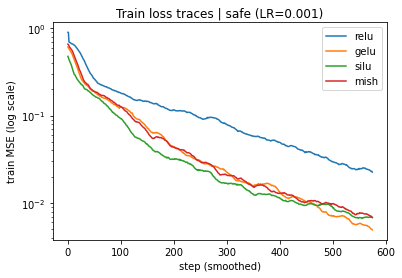

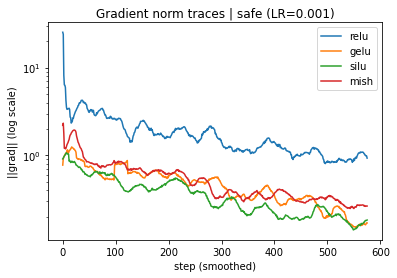

In [23]:
plot_traces("safe", title_suffix=f"(LR={LR_SAFE})")

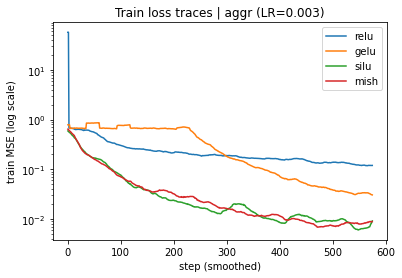

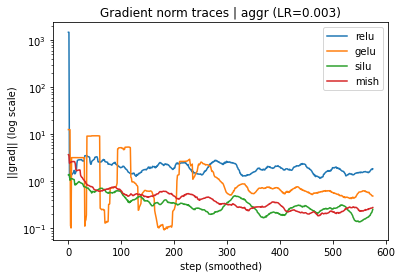

In [24]:
plot_traces("aggr", title_suffix=f"(LR={LR_AGGR})")

## 6) Числовые метрики стабильности

Считаем статистики на хвосте траектории (последние `tail_k` шагов):
- `dloss_std_tail` — стандартное отклонение приращений loss (мера «пилы»)
- `gnorm_std_tail` — разброс норм градиента

Сравниваем для SAFE и AGGR режимов.


In [25]:
def print_stability_table(mode, tail_k=300):
    print(f"\n=== Stability metrics | {mode} | tail_k={tail_k} ===")
    rows = []
    for act in acts:
        loss = runs[mode][act]["loss"]
        g = runs[mode][act]["gnorm"]
        m = stability_metrics(loss, g, tail_k=tail_k)
        rows.append((act, m["loss_mean_tail"], m["dloss_std_tail"], m["gnorm_mean_tail"], m["gnorm_std_tail"]))

    # pretty print
    print(f"{'act':<6} | {'loss_mean':>10} | {'std(dloss)':>10} | {'gnorm_mean':>10} | {'gnorm_std':>10}")
    print("-"*62)
    for r in rows:
        act, lm, dls, gm, gs = r
        print(f"{act:<6} | {lm:>10.4e} | {dls:>10.4e} | {gm:>10.4e} | {gs:>10.4e}")

In [26]:
print_stability_table("safe", tail_k=300)


=== Stability metrics | safe | tail_k=300 ===
act    |  loss_mean | std(dloss) | gnorm_mean |  gnorm_std
--------------------------------------------------------------
relu   | 4.4126e-02 | 7.5826e-03 | 1.1074e+00 | 5.2885e-01
gelu   | 1.1849e-02 | 2.4852e-03 | 2.9771e-01 | 1.4540e-01
silu   | 1.0794e-02 | 2.2240e-03 | 2.2203e-01 | 9.0795e-02
mish   | 1.2418e-02 | 2.5435e-03 | 3.2391e-01 | 1.0581e-01


In [27]:
print_stability_table("aggr", tail_k=300)


=== Stability metrics | aggr | tail_k=300 ===
act    |  loss_mean | std(dloss) | gnorm_mean |  gnorm_std
--------------------------------------------------------------
relu   | 1.5111e-01 | 2.2463e-02 | 1.7806e+00 | 9.4884e-01
gelu   | 7.5534e-02 | 1.5901e-02 | 6.1421e-01 | 2.8220e-01
silu   | 1.1086e-02 | 4.3851e-03 | 2.6623e-01 | 1.3809e-01
mish   | 1.0210e-02 | 2.6192e-03 | 2.6273e-01 | 1.0146e-01


## 8)

1) **Траектория loss по minibatch-ам**: у некоторых активаций заметно ниже дисперсия функции потерь в ходе обучения.

2) **std(Δloss)** и **std(||grad||)** на этапе насыщения: что продемонстрировано?
